Background: 
This data set was found on kaggle.com created by Palak Jain used for this project contains data on 1,000 drugs and their side effects. The goal of this project is to find if there is a correlation between higher dosage and improvement score, longer treatment and improvement score, and side effect frequency of the top 5 prescribed drugs.

Loading and Cleaning the Data: 
Only minimal cleaning was needed for the variables of interest where I checked if there were any NA values in dosage, improvement score, and treatment duration. Checked if any dosage values were less than or equal to 0. Checked if any scores were less than 0 or greater than 10. Checked if any treatments days were less than 0. Standardized side effect names, drug names, and conditions where they all have the same capitalization and removed any extra spaces. 

In [58]:
import pandas as pd

drug = pd.read_csv('real_drug_dataset.csv')

NA_Dosage = drug['Dosage_mg'].isnull().any()
print(NA_Dosage)
NA_Score = drug['Improvement_Score'].isnull().any()
print(NA_Dosage)
NA_Treatment_Days = drug['Treatment_Duration_days'].isnull().any()
print(NA_Treatment_Days)

has_zeros_dosage = (drug['Dosage_mg'] <= 0).any()
print(has_zeros_dosage)
has_incorrect_score = ((drug['Improvement_Score'] < 0) | (drug['Improvement_Score'] > 10)).any()
print(has_incorrect_score)
has_nonsense_days = (drug['Treatment_Duration_days'] < 0).any()
print(has_nonsense_days)


drug['Side_Effects'] = drug['Side_Effects'].str.strip().str.lower()
drug['Drug_Name'] = drug['Drug_Name'].str.strip().str.lower()
drug['Condition'] = drug['Condition'].str.strip().str.lower()

drug = drug.drop(columns = ['Patient_ID','Age','Gender'])


False
False
False
False
False
False


Final Data Set: The final drug data set includes the variables Condition, which is the illness or condition being treated, Drug_Name, which is the name of the drug, Dosage_mg, which is the dosage of the drug in milligrams, Treatment_Duration_days which is the number of days the treatment lasted, Side_Effects, which were the reported side effects during treatment, and Improvement_Score, which is the score indicating the patient's level of improvement after treatment. Patient_ID, Age, and Gender were removed as these variables would not be useful for the stated objective. 

Exploratory Data Analysis
Summary of dosage, treatment duration, and improvement score showing that the values make sense for this problem where minimum dosage is not less than 0, treatment duration minimum is not less than 0, and improvement score minimum is not less than 0 or max is greater than 10.

In [59]:
print(drug.describe())


         Dosage_mg  Treatment_Duration_days  Improvement_Score
count  1000.000000               1000.00000        1000.000000
mean    352.650000                 32.38000           7.015200
std     295.419617                 15.69809           1.425609
min      50.000000                  5.00000           2.500000
25%     100.000000                 19.00000           6.100000
50%     250.000000                 32.00000           7.000000
75%     500.000000                 46.00000           8.000000
max     850.000000                 59.00000          10.000000


Text(0, 0.5, 'Improvement Score ')

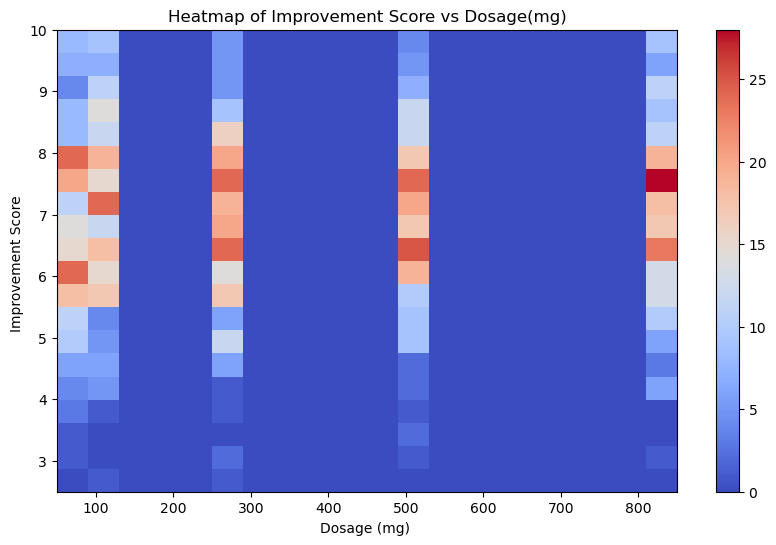

In [60]:
import matplotlib.pyplot as plt
import numpy as np

x = drug['Dosage_mg']
y = drug['Improvement_Score']

heatmap, xedges, yedges = np.histogram2d(x, y, bins=20)
plt.figure(figsize=(10, 6))
plt.imshow(
    heatmap.T,
    origin='lower',
    cmap='coolwarm',
    aspect='auto',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)

plt.colorbar();

plt.title("Heatmap of Improvement Score vs Dosage(mg)")
plt.xlabel("Dosage (mg) ")
plt.ylabel("Improvement Score ")

The first figure is a heatmap comparing improvement score vs dosage where the colorbar shows that when the data is closer to red that many patients had a combination of a specific dosage-score while closer to blue represents that very few or zero patients had that dosage-score combination. It can be seen that the improvement score increases consistently across all dosage levels where scores tend to cluster around a score from 6 to 8 for all dosages. As this pattern for improvement score is shown for all dosage levels, it can be said that dosage level has no strong effect on improvement score as the 800 mg has the same score spread as the 100 mg. 

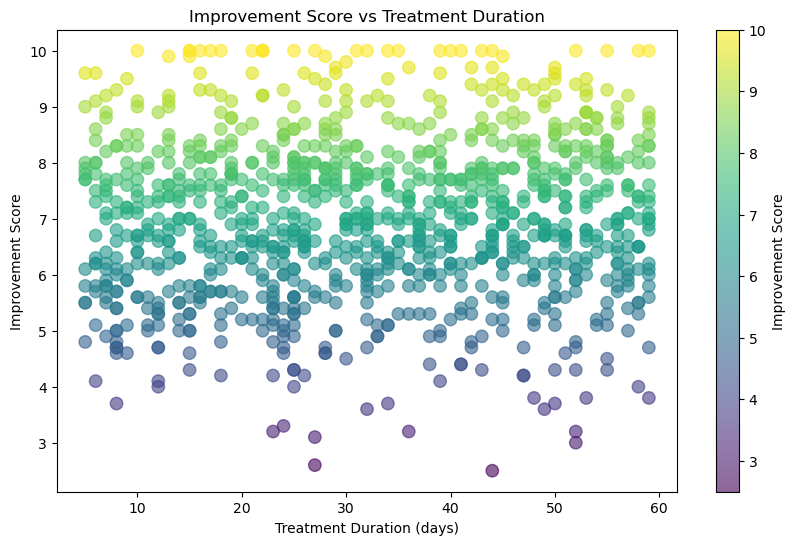

In [61]:
x = drug['Treatment_Duration_days']
y = drug['Improvement_Score']

plt.figure(figsize=(10, 6))

plt.scatter(
    x, 
    y,
    c=y,                 
    s=80,                
    alpha=0.6,
    cmap='viridis'     
)

plt.colorbar(label="Improvement Score")

plt.title("Improvement Score vs Treatment Duration")
plt.xlabel("Treatment Duration (days)")
plt.ylabel("Improvement Score")

plt.show()

Since there was no effect with dosage, I then evaluated the relationship between improvement score and treatment duration to see if treatment duration may be effecting improvement score. The second figure is a scatter plot comparing improvement score vs treatment duration where it can be seen that there is little correlation between the two as most scores are concentrated between 5.5 to 8 from 0 - 60 days. It can be noted that for scores below 3.5 they start around 20 days of treatment which could indicate that patient's are more likely to give lower scores the longer they are treated. No 10s were given for treatment days less than 10.

The next idea investigated was the frequency of side effects of each drug. I first picked which side effects I would focus on by creating a pie chart of the top 10 most reported side effects for all drugs and then taking the top 5. I then found the top 5 most common drugs that are described. 

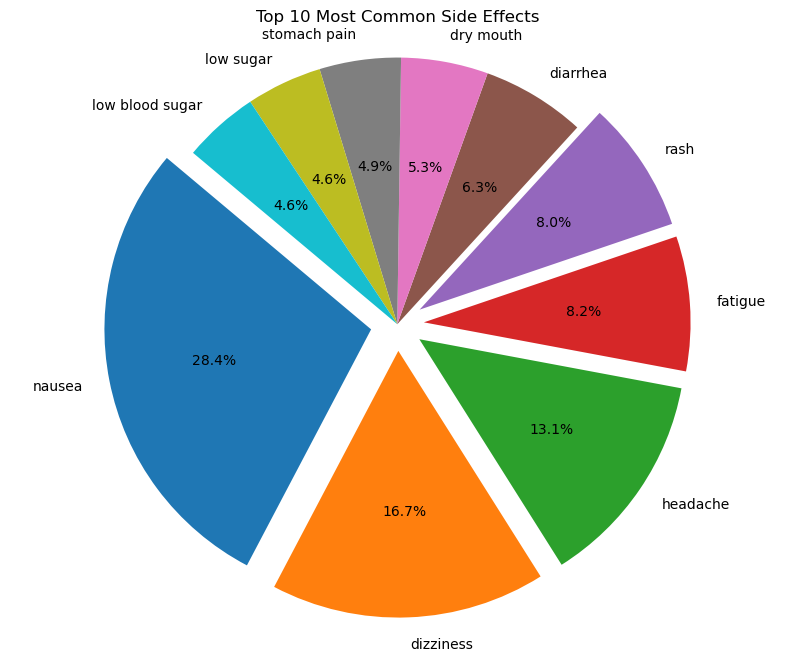

Drug_Name
tramadol            82
ciprofloxacin       79
insulin glargine    78
amlodipine          74
azithromycin        70
Name: count, dtype: int64


In [62]:
side_effect_counts = drug['Side_Effects'].value_counts().head(10)

color = ['blue','orange','red','green','purple','cyan','pink','gray','yellow','maroon']
plt.figure(figsize=(10, 8))
explode_values = [0.1,0.1,0.1,0.1,0.1,0,0,0,0,0]
plt.pie(
    side_effect_counts,
    labels=side_effect_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode_values
)

plt.title("Top 10 Most Common Side Effects")
plt.axis('equal')

plt.show()

top5_drugs = drug['Drug_Name'].value_counts().head(5)
print(top5_drugs)

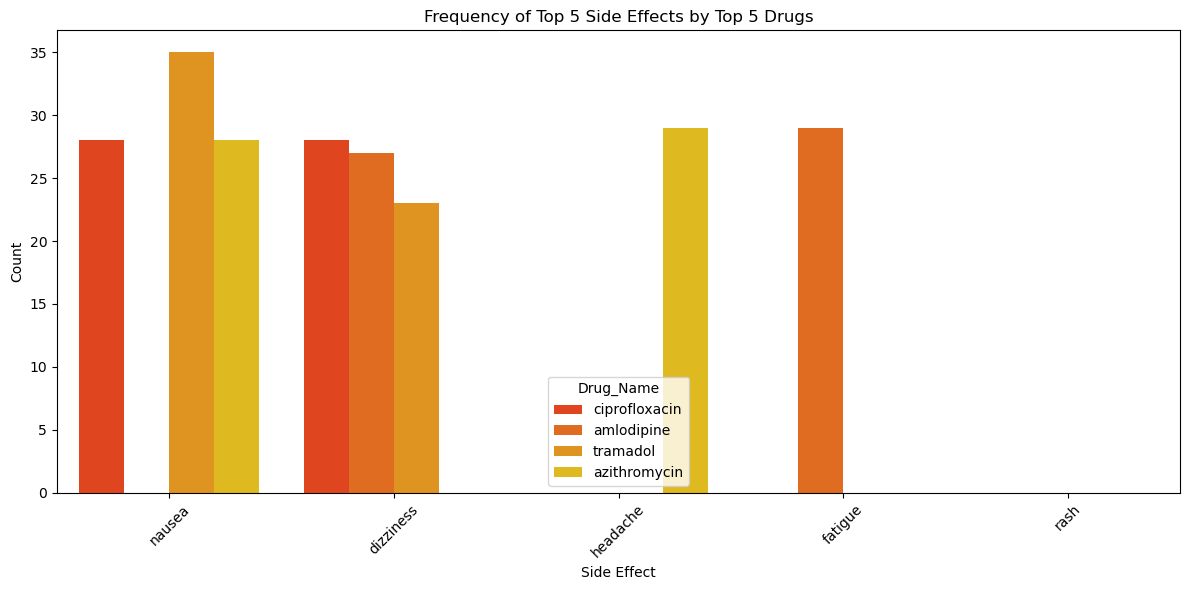

In [63]:
import seaborn as sns

top5_drugs = drug['Drug_Name'].value_counts().head(5).index
top5_side_effects = drug['Side_Effects'].value_counts().head(5).index

drug_filtered = drug[
    drug['Drug_Name'].isin(top5_drugs) &
    drug['Side_Effects'].isin(top5_side_effects)
]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=drug_filtered,
    x='Side_Effects',
    hue='Drug_Name',
    order=top5_side_effects,
    palette="autumn"
)

plt.title("Frequency of Top 5 Side Effects by Top 5 Drugs")
plt.xlabel("Side Effect")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The figure above is a count plot of the frequency of the top 5 side effects compared to the top 5 most prescribed drugs. It is shown that insulin glargine does not appear in the figure, meaning that it causes side effects out of the top 5 most common. No one drug causes more than two of the top 5 most common side effects. Only azithromycin causes headaches while only amlodipine causes fatigue. None of the top 5 drugs causes rash. This data overall is a good indicator of what side effects patients will most likely have after taking these drugs and supports the idea from the pie chart that nausea and dizziness are very common side effects from a variety of drugs.  

Conclusion:
The correlation between higher dosage and improvement score and longer treatment duration and improvement score was proven to not exist where scores were in the same ranges for all dosages and all periods of time. Some interesting observations can be made, however, where scores tend to be around 6 to 8 and that treatment days less than 20 days did not have scores lower than 3.5 but days longer than 20 did. The last two figures helps visualize how nausea and dizziness are some of the more common side effects that the top 5 most prescribed medicine would cause to people. This gives people an idea of what to expect when they take them. In the future, other categories like gender and age could be explored to see how they would effect the frequency of side effects and improvement score.  

References:
https://www.kaggle.com/datasets/palakjain9/1000-drugs-and-side-effects?resource=download 